In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse
import math  
import sklearn.metrics 
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Resumen

1. Crear la matriz de usuarios/películas
2. Normalización de los datos
3. Crear la matriz de similitud
4. KN-Neighbours
5. Mejor K y distancia para KN-Neighbours
6. Accuracy Promedio
7. Predicciones

## 1. Crear la matriz usuarios/películas

In [33]:
df = pd.read_csv('BBDD_1M/ratings.dat', delimiter='::', engine='python', header=None, names=['userId', 'movieId', 'rating', 'timestamp'], encoding='ISO-8859-1')
df.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [35]:
indice=list(df['userId'].unique())
columnas=list(df['movieId'].unique())
indice=sorted(indice)
columnas=sorted(columnas)
 
escasez=pd.pivot_table(data=df,values='rating',index='userId',columns='movieId')
escasez.head(10)

movieId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN


## 2. Normalización de los datos

1. **Crear una copia de la matriz:** La función primero crea una copia de la matriz original de calificaciones para evitar modificar los datos originales durante el proceso de normalización.
2. **Normalización individual por usuario:**

Para cada usuario, seleccionamos solo las calificaciones que no son NaN (es decir, las películas que el usuario ha calificado). Esto asegura que solo trabajamos con datos válidos, y los valores NaN (calificaciones ausentes) no afectan el cálculo. \
Usamos StandardScaler para transformar las calificaciones del usuario. StandardScaler ajusta las calificaciones para que tengan una media de 0 y una desviación estándar de 1.\

*Esto tiene dos beneficios:* \
Centrado en 0: Las calificaciones se centran alrededor de 0, eliminando el sesgo de usuarios que tienden a calificar de manera consistentemente alta o baja.\
Ajuste de variabilidad: La desviación estándar se ajusta a 1, lo que permite comparar las calificaciones de usuarios con diferentes patrones de calificación en una escala uniforme.\

3. **Mantener NaN donde no hay calificaciones:** Después de normalizar las calificaciones de cada usuario, colocamos los valores normalizados en sus posiciones originales en la matriz. Los valores NaN permanecen sin alterarse, conservando así la estructura de la matriz original.

4. **Reemplazo de NaN por 0:** Finalmente, los valores NaN en la matriz normalizada se reemplazan con 0. Esto es importante para algoritmos de aprendizaje automático, ya que evita la presencia de valores NaN en la matriz final y permite trabajar con una matriz completa.

In [36]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

def normalizar_datos(matriz_escasez):
    # Creamos una copia de la matriz para evitar modificar el original
    matriz_escasez_copy = matriz_escasez.copy()
    
    # Inicializamos StandardScaler sin centrado en 0 debido a NaNs
    scaler = StandardScaler(with_mean=True, with_std=True)
    
    # Aplicamos la normalización solo en las columnas que tienen datos no NaN
    for user_id in matriz_escasez_copy.index:
        # Seleccionamos las calificaciones del usuario (excluyendo NaNs)
        user_ratings = matriz_escasez_copy.loc[user_id].dropna()
        if not user_ratings.empty:
            # Normalizamos las calificaciones de este usuario
            normalized_ratings = scaler.fit_transform(user_ratings.values.reshape(-1, 1)).flatten()
            # Colocamos los valores normalizados en la matriz original, manteniendo NaNs donde no hay calificaciones
            matriz_escasez_copy.loc[user_id, user_ratings.index] = normalized_ratings
    
    # Llenamos los NaNs con 0
    matriz_escasez_copy = matriz_escasez_copy.fillna(0)
    return matriz_escasez_copy



In [37]:
matriz_normalizada = normalizar_datos(escasez)
matriz_normalizada.head(20)

movieId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,1.202827,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
5,0.000000,0.000000,0.0,0.000000,0.0,-1.014718,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
6,0.119523,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
7,0.000000,0.000000,0.0,0.000000,0.0,-0.438529,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
8,0.124848,0.000000,0.0,-0.959767,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
9,1.548952,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,-0.901629,0.0,0.0,0.0,0.0


También es necesario reescalar la predicción que se ha hecho, por tanto aplicamos el cálculo a la inversa, y además hacemos un .clip() para que las calificaciones no sean menores a 0.5 o mayores de 5

In [38]:
def reescalar_predicciones(predicciones_normalizadas, matriz_escasez_original, min_rating=0.5, max_rating=5.0):
    # Calculamos la media y desviación estándar de cada usuario ignorando los NaNs originales
    medias_usuarios = matriz_escasez_original.mean(axis=1, skipna=True)
    desviaciones_usuarios = matriz_escasez_original.std(axis=1, skipna=True)
    
    # Aplicamos la transformación inversa sólo donde había datos originales
    predicciones_reescaladas = predicciones_normalizadas.mul(desviaciones_usuarios, axis=0).add(medias_usuarios, axis=0)
    predicciones_reescaladas = predicciones_reescaladas.where(~matriz_escasez_original.isna(), np.nan)
    predicciones_reescaladas = predicciones_reescaladas.round()
    predicciones_reescaladas = predicciones_reescaladas.clip(lower=min_rating, upper=max_rating)
    
    return predicciones_reescaladas



Como se puede ver a continuacion la matriz obtenida es exactamente igual que la principal

In [39]:
predicciones_reescaladas = reescalar_predicciones(matriz_normalizada, escasez)
predicciones_reescaladas.head(20)


movieId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN


## 5. Mejor K y distancia para K-Nearest Neighbours

In [40]:
def peliculas_del_usuario(usuario, matriz_escasez):
    # Filtramos las películas que no tienen valor NaN para el usuario
    usuario_data = matriz_escasez.iloc[usuario].dropna()

    # Obtenemos las películas y sus valoraciones
    lista_peliculas = usuario_data.index.tolist()  # Películas votadas
    valoraciones_originales = usuario_data.values.tolist()  # Valoraciones correspondientes

    # print("ID's de películas votadas por el usuario: " + str(lista_peliculas[:10]) + "... (total: " + str(len(lista_peliculas)) + ")")
    # print("Valoraciones de las películas votadas por el usuario: " + str(valoraciones_originales[:10]) + "... (total: " + str(len(valoraciones_originales)) + ")")
    
    return lista_peliculas, valoraciones_originales


In [41]:
def peliculas_con_minimo_vecinos(lista_peliculas_usuario, valoraciones_peliculas, matriz_normalizada, vecinos_min):
    # Filtramos solo las películas con al menos 'vecinos_min' valoraciones distintas de 0
    peliculas_filtradas = []
    valoraciones_filtradas = []
    
    for i, pelicula in enumerate(lista_peliculas_usuario):
        # Asegurarse de que 'pelicula' es el identificador correcto que corresponde a las columnas de usuario_pelicula
        if pelicula not in matriz_normalizada.columns:
            print(f"Película {pelicula} no encontrada en las columnas.")
            continue
        
        # Seleccionamos los usuarios que vieron la película, es decir, aquellos con valoraciones != 0
        usuarios_que_vieron_la_pelicula = matriz_normalizada[matriz_normalizada[pelicula].notna() & (matriz_normalizada[pelicula] != 0)][pelicula]
        
        # Si el número de usuarios que vieron la película es mayor o igual a 'vecinos_min', la añadimos a la lista
        if len(usuarios_que_vieron_la_pelicula) >= vecinos_min:
            peliculas_filtradas.append(pelicula)
            valoraciones_filtradas.append(valoraciones_peliculas[i])  # Añadimos la valoración correspondiente

    return peliculas_filtradas, valoraciones_filtradas


In [60]:
def reescalar_prediccion(prediccion_normalizada, id_usuario, matriz_escasez_original, min_rating=1, max_rating=5.0):
    # Calculamos la media y desviación estándar del usuario específico
    media_usuario = matriz_escasez_original.loc[id_usuario].mean(skipna=True)
    desviacion_usuario = matriz_escasez_original.loc[id_usuario].std(skipna=True)
    
    # Si la desviación estándar es válida, aplicamos el reescalado
    if not pd.isna(media_usuario) and not pd.isna(desviacion_usuario):
        prediccion_reescalada = (prediccion_normalizada * desviacion_usuario) + media_usuario
        # Clipping para mantener la predicción dentro del rango y redondeo
        prediccion_reescalada = np.clip(round(prediccion_reescalada, 2), min_rating, max_rating)
    else:
        prediccion_reescalada = np.nan
    
    return prediccion_reescalada

def similitud_distancias(lista_peliculas_usuario, usuario, distancia_escogida, vecinos, minkowski=False):
    lista_similitud = []
    usuario_objetivo = matriz_normalizada.iloc[[usuario]]  # Datos del usuario objetivo
    
    # Recorrer las películas votadas por el usuario
    for pelicula in lista_peliculas_usuario:
        # Seleccionamos las valoraciones de los usuarios que han visto la película y que no tienen valoraciones nulas o 0
        usuarios_que_vieron_la_pelicula_con_nulls = matriz_normalizada[pelicula]
        usuarios_que_vieron_la_pelicula = matriz_normalizada[usuarios_que_vieron_la_pelicula_con_nulls.notna() & (usuarios_que_vieron_la_pelicula_con_nulls != 0)]
        usuarios_que_vieron_la_pelicula_con_nulls = usuarios_que_vieron_la_pelicula_con_nulls.loc[usuarios_que_vieron_la_pelicula.index]

        knn = KNeighborsRegressor(metric=distancia_escogida, p=3 if minkowski else None, n_neighbors=vecinos)
        knn.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls) # Ajustar el modelo
        
        # Predecir para el usuario objetivo
        prediccion_usuario = knn.predict(usuario_objetivo)
        
        # Reescalar la predicción para que esté dentro del rango adecuado
        prediccion_reescalada = reescalar_prediccion(prediccion_usuario[0],id_usuario, escasez)
        
        lista_similitud.append(prediccion_reescalada)  # Añadir la predicción reescalada a la lista de similitudes

    return lista_similitud

In [43]:
def mejor_cantidad_de_vecinos(usuario, lista_peliculas, valoraciones_peliculas, min_vecinos, distancia_escogida, minkowski=False):
    mejor_k = None
    mejor_error = float('inf')
    resultados_vecinos = []

    for k in range(2, min_vecinos):
        # Obtenemos las predicciones utilizando similitud_distancias
        similitud = similitud_distancias(lista_peliculas, usuario, distancia_escogida, k, minkowski)
        
        # Calculamos el error con las valoraciones originales no normalizadas
        evaluacion = sklearn.metrics.mean_squared_error(valoraciones_peliculas, similitud)
        resultados_vecinos.append(evaluacion)
        
        print("Cuando usamos k= " + str(k) + " obtenemos " + str(evaluacion))
        
        if evaluacion < mejor_error:
            mejor_k = k
            mejor_error = evaluacion
    
    print("Mejor resultado obtenido con la distancia " + distancia_escogida + " es K = " + str(mejor_k))

    # Graficamos el MSE para diferentes valores de k
    plt.plot(range(1, len(resultados_vecinos) + 1), resultados_vecinos)
    plt.xlabel('Número de vecinos (k)')
    plt.ylabel('Error (MSE)')
    plt.title(f'Evolución del MSE según k (Distancia: {distancia_escogida})')
    plt.show()

    return mejor_k,resultados_vecinos


Aqui utilizaremos un usuario con la misma cantidad de vecinos que en la base de datos de 100K, para tener resultados lo mas parecidos posibles, es decir las 50 primeras peliculas de un usuario con 216.

In [61]:
data_100K = pd.read_csv("BBDD_100K/ratings.csv")
user_3_ratings = data_100K[data_100K['userId'] == 4]

# Contar la cantidad de películas distintas valoradas por el usuario
num_movies_rated = user_3_ratings['movieId'].nunique()
print(f"El usuario con ID 3 ha valorado {num_movies_rated} películas diferentes.")

El usuario con ID 3 ha valorado 216 películas diferentes.


In [62]:
user_movie_counts = df.groupby('userId')['movieId'].nunique()

# Filtrar para encontrar usuarios con exactamente 216 películas valoradas
user_with_216_ratings = user_movie_counts[user_movie_counts == 216]
print(user_with_216_ratings)

userId
3665    216
5927    216
Name: movieId, dtype: int64


Usaremos el usuario 3665

In [63]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial import distance_matrix
from scipy.spatial.distance import euclidean, pdist, squareform
from sklearn.model_selection import GridSearchCV, cross_val_score

In [64]:
id_usuario=3664 # 1 menos para la lista
min_vecinos = 20
# lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario,escasez)
lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(id_usuario,escasez)
lista_peliculas = lista_peliculas[0:50] #limitaremos a 50 las peliculas
valoraciones_peliculas = valoraciones_peliculas[0:50] #limitaremos a 50 las peliculas


In [65]:
# Obtener identificadores de películas
lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(lista_peliculas_usuario=lista_peliculas, valoraciones_peliculas=valoraciones_peliculas, matriz_normalizada=matriz_normalizada, vecinos_min=min_vecinos)
similitudes = similitud_distancias(lista_peliculas_usuario=lista_peliculas, usuario=id_usuario, distancia_escogida='euclidean', vecinos=min_vecinos)
print(similitudes)


[3.76, 3.0, 3.21, 3.82, 3.94, 3.47, 2.29, 3.25, 2.69, 2.26, 3.29, 2.93, 2.55, 3.14, 2.62, 2.74, 3.15, 3.63, 2.85, 2.9, 3.49, 2.7, 2.66, 2.91, 3.01, 2.61, 3.33, 3.07, 2.8, 2.69, 2.98, 2.75, 3.97, 3.07, 2.36, 3.87, 3.63, 3.84, 2.98, 3.76, 3.98, 3.19, 2.61, 2.79, 2.27, 2.75, 3.08, 3.0, 2.62, 3.56]


Ahora lo que voy a hacer es calcular la mejor K en todas las distancias posibles, la distancia que de menor error y con la K mas grande será la mas indicada para utilizarse

In [66]:
def evaluar_todas_las_distancias(usuario, lista_peliculas, valoraciones_peliculas, min_vecinos):
    distancias = ['euclidean', 'manhattan', 'cosine', 'jaccard', 'chebyshev', 'minkowski']
    errores_por_distancia = {}
    
    for distancia in distancias:
        print(f"\nEvaluando con la distancia: {distancia}")
        _, errores = mejor_cantidad_de_vecinos(usuario, lista_peliculas, valoraciones_peliculas, min_vecinos, distancia, minkowski=(distancia=='minkowski'))
        errores_por_distancia[distancia] = errores
        
    return errores_por_distancia

def graficar_errores_por_distancia(errores_por_distancia, min_vecinos):
    plt.figure(figsize=(10, 6))
    
    for distancia, errores in errores_por_distancia.items():
        plt.plot(range(2, min_vecinos), errores, label=f'{distancia}')
    
    plt.xlabel('Número de vecinos (k)')
    plt.ylabel('Error (MSE)')
    plt.title('Comparación de MSE por diferentes distancias y número de vecinos (k)')
    plt.legend()
    plt.show()


Evaluando con la distancia: euclidean
Cuando usamos k= 2 obtenemos 0.9288620000000001
Cuando usamos k= 3 obtenemos 1.1757999999999997
Cuando usamos k= 4 obtenemos 1.196164
Cuando usamos k= 5 obtenemos 1.249718
Cuando usamos k= 6 obtenemos 1.250492
Cuando usamos k= 7 obtenemos 1.286146
Cuando usamos k= 8 obtenemos 1.270774
Cuando usamos k= 9 obtenemos 1.320196
Cuando usamos k= 10 obtenemos 1.351128
Cuando usamos k= 11 obtenemos 1.284922
Cuando usamos k= 12 obtenemos 1.332638
Cuando usamos k= 13 obtenemos 1.3436320000000002
Cuando usamos k= 14 obtenemos 1.3562699999999999
Cuando usamos k= 15 obtenemos 1.336894
Cuando usamos k= 16 obtenemos 1.356138
Cuando usamos k= 17 obtenemos 1.3390039999999999
Cuando usamos k= 18 obtenemos 1.3396020000000002
Cuando usamos k= 19 obtenemos 1.353926
Mejor resultado obtenido con la distancia euclidean es K = 2


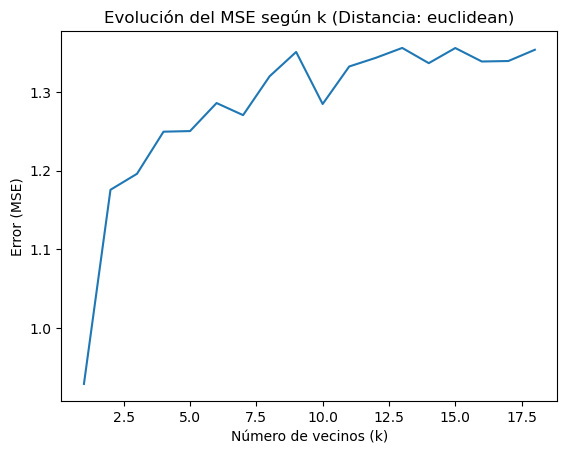


Evaluando con la distancia: manhattan
Cuando usamos k= 2 obtenemos 0.909902
Cuando usamos k= 3 obtenemos 1.168656
Cuando usamos k= 4 obtenemos 1.24684
Cuando usamos k= 5 obtenemos 1.3287879999999999
Cuando usamos k= 6 obtenemos 1.3695220000000001
Cuando usamos k= 7 obtenemos 1.343602
Cuando usamos k= 8 obtenemos 1.4376520000000002
Cuando usamos k= 9 obtenemos 1.439984
Cuando usamos k= 10 obtenemos 1.4229759999999998
Cuando usamos k= 11 obtenemos 1.4261700000000002
Cuando usamos k= 12 obtenemos 1.4422100000000002
Cuando usamos k= 13 obtenemos 1.428762
Cuando usamos k= 14 obtenemos 1.39584
Cuando usamos k= 15 obtenemos 1.4069019999999997
Cuando usamos k= 16 obtenemos 1.4233680000000002
Cuando usamos k= 17 obtenemos 1.417134
Cuando usamos k= 18 obtenemos 1.441194
Cuando usamos k= 19 obtenemos 1.4367300000000003
Mejor resultado obtenido con la distancia manhattan es K = 2


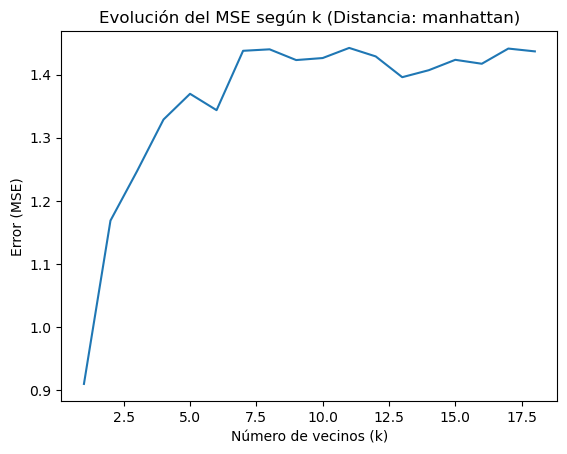


Evaluando con la distancia: cosine
Cuando usamos k= 2 obtenemos 0.847054
Cuando usamos k= 3 obtenemos 0.9091699999999999
Cuando usamos k= 4 obtenemos 0.8948240000000002
Cuando usamos k= 5 obtenemos 0.9514139999999998
Cuando usamos k= 6 obtenemos 1.0122819999999997
Cuando usamos k= 7 obtenemos 1.0370640000000002
Cuando usamos k= 8 obtenemos 1.0250000000000001
Cuando usamos k= 9 obtenemos 1.006574
Cuando usamos k= 10 obtenemos 1.0413799999999998
Cuando usamos k= 11 obtenemos 1.0612059999999999
Cuando usamos k= 12 obtenemos 1.083976
Cuando usamos k= 13 obtenemos 1.102744
Cuando usamos k= 14 obtenemos 1.065544
Cuando usamos k= 15 obtenemos 1.060748
Cuando usamos k= 16 obtenemos 1.0415960000000002
Cuando usamos k= 17 obtenemos 1.039814
Cuando usamos k= 18 obtenemos 1.03261
Cuando usamos k= 19 obtenemos 1.0469080000000002
Mejor resultado obtenido con la distancia cosine es K = 2


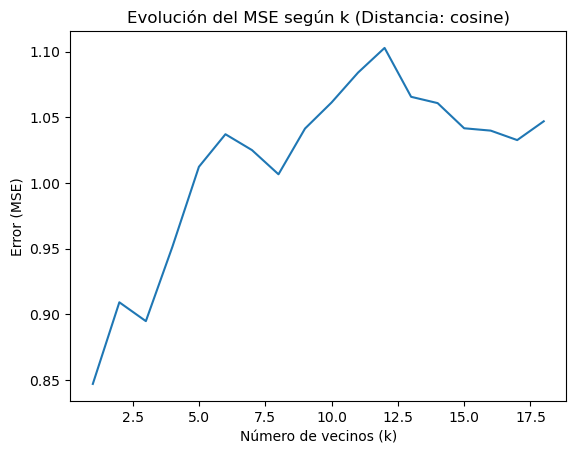


Evaluando con la distancia: jaccard
Cuando usamos k= 2 obtenemos 1.164962
Cuando usamos k= 3 obtenemos 1.200198
Cuando usamos k= 4 obtenemos 1.150096
Cuando usamos k= 5 obtenemos 1.163184
Cuando usamos k= 6 obtenemos 1.2214260000000001
Cuando usamos k= 7 obtenemos 1.2947799999999998
Cuando usamos k= 8 obtenemos 1.297166
Cuando usamos k= 9 obtenemos 1.2608039999999998
Cuando usamos k= 10 obtenemos 1.2608240000000002
Cuando usamos k= 11 obtenemos 1.263314
Cuando usamos k= 12 obtenemos 1.2765119999999999
Cuando usamos k= 13 obtenemos 1.225474
Cuando usamos k= 14 obtenemos 1.2562499999999999
Cuando usamos k= 15 obtenemos 1.23333
Cuando usamos k= 16 obtenemos 1.2323719999999998
Cuando usamos k= 17 obtenemos 1.236576
Cuando usamos k= 18 obtenemos 1.2386899999999998
Cuando usamos k= 19 obtenemos 1.2160579999999999
Mejor resultado obtenido con la distancia jaccard es K = 4


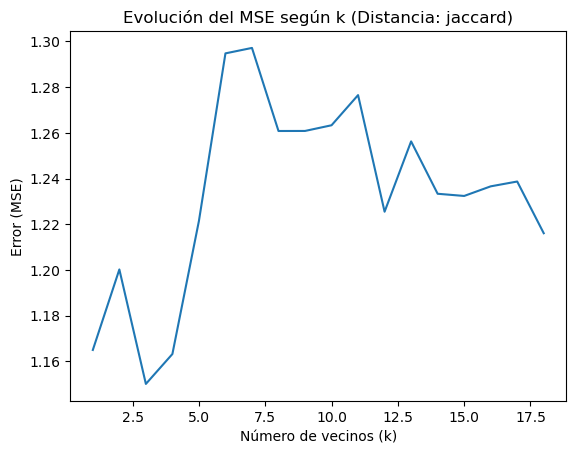


Evaluando con la distancia: chebyshev
Cuando usamos k= 2 obtenemos 0.710154
Cuando usamos k= 3 obtenemos 0.9014099999999999
Cuando usamos k= 4 obtenemos 0.9494500000000001
Cuando usamos k= 5 obtenemos 1.0343780000000002
Cuando usamos k= 6 obtenemos 1.01638
Cuando usamos k= 7 obtenemos 1.112834
Cuando usamos k= 8 obtenemos 0.9984740000000001
Cuando usamos k= 9 obtenemos 1.0313839999999999
Cuando usamos k= 10 obtenemos 1.02523
Cuando usamos k= 11 obtenemos 1.0767440000000001
Cuando usamos k= 12 obtenemos 1.07708
Cuando usamos k= 13 obtenemos 1.061482
Cuando usamos k= 14 obtenemos 1.071088
Cuando usamos k= 15 obtenemos 1.0675379999999999
Cuando usamos k= 16 obtenemos 1.077194
Cuando usamos k= 17 obtenemos 1.068564
Cuando usamos k= 18 obtenemos 1.0932039999999998
Cuando usamos k= 19 obtenemos 1.087244
Mejor resultado obtenido con la distancia chebyshev es K = 2


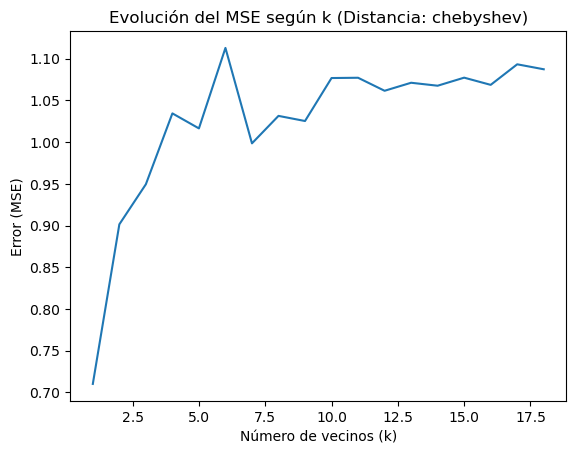


Evaluando con la distancia: minkowski
Cuando usamos k= 2 obtenemos 0.898106
Cuando usamos k= 3 obtenemos 1.2294599999999998
Cuando usamos k= 4 obtenemos 1.200926
Cuando usamos k= 5 obtenemos 1.2139960000000003
Cuando usamos k= 6 obtenemos 1.26922
Cuando usamos k= 7 obtenemos 1.257178
Cuando usamos k= 8 obtenemos 1.2776660000000002
Cuando usamos k= 9 obtenemos 1.3017239999999999
Cuando usamos k= 10 obtenemos 1.308174
Cuando usamos k= 11 obtenemos 1.2880440000000002
Cuando usamos k= 12 obtenemos 1.284222
Cuando usamos k= 13 obtenemos 1.294924
Cuando usamos k= 14 obtenemos 1.3200939999999997
Cuando usamos k= 15 obtenemos 1.318106
Cuando usamos k= 16 obtenemos 1.2914420000000002
Cuando usamos k= 17 obtenemos 1.318586
Cuando usamos k= 18 obtenemos 1.3072500000000002
Cuando usamos k= 19 obtenemos 1.2858580000000002
Mejor resultado obtenido con la distancia minkowski es K = 2


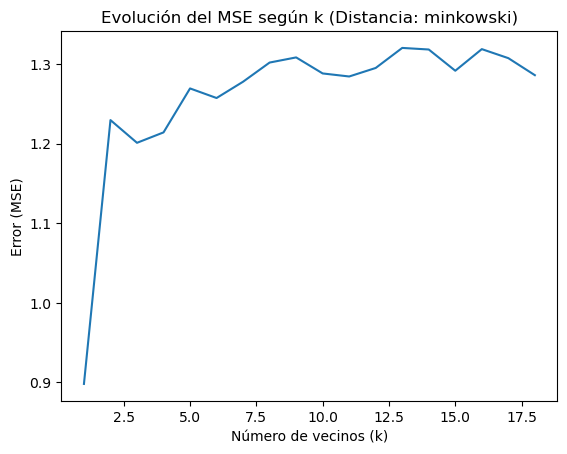

In [67]:
errores_por_distancia = evaluar_todas_las_distancias(usuario=id_usuario, lista_peliculas=lista_peliculas, valoraciones_peliculas=valoraciones_peliculas, min_vecinos=min_vecinos)

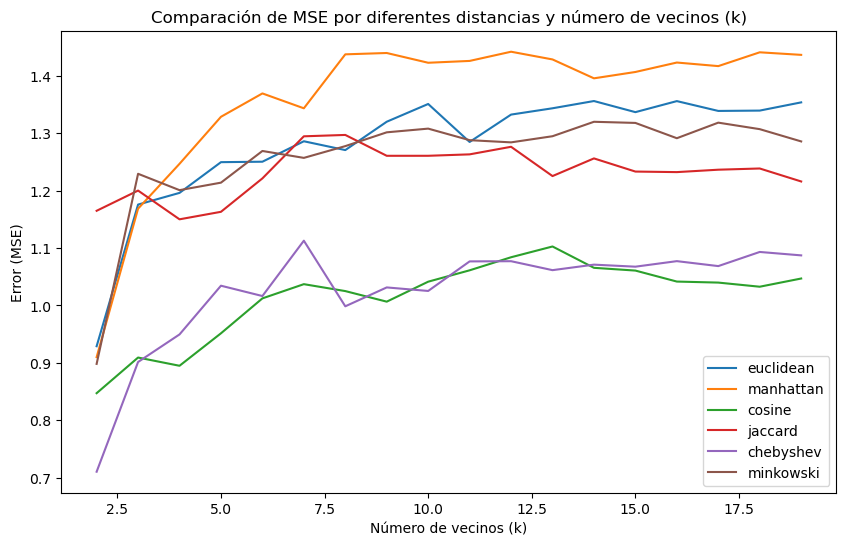

In [68]:
graficar_errores_por_distancia(errores_por_distancia=errores_por_distancia, min_vecinos=min_vecinos)

### Conclusión sobre la Elección de K Vecinos y Distancia

En este caso parece que una mayor vecinidad no está beneficiando tanto al algoritmo como lo hacia en 100K, realmente sigue sin interesarnos una K muy pequeña, pero como la diferencia entre la K pequeña y la mas grande es mucho mayor que en 100K, si que podriamos asumir que una K mas baja no está tan mal.

De igual manera podemos corroborar que la distancia de Cosine y Chebyshev son las que mejor se comportan en el uso de KNN para sistemas de recomendación.
En este caso usaremos K = 5 (2 me parece demasiado baja) de la distancia cosine, aun asi voy a mostrar los resultados con cada mejor K

### Ejecutar el codigo de cada algoritmo para las mejores K de cada algoritmo

In [69]:
usuario = 3664
minimo_vecinos = 20

# Obtener lista de películas y valoraciones
lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario, escasez)
lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(
    lista_peliculas_usuario=lista_peliculas, 
    valoraciones_peliculas=valoraciones_peliculas, 
    matriz_normalizada=matriz_normalizada, 
    vecinos_min=minimo_vecinos
)

# Similitud Euclidean
similitud_euclideana = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='euclidean', 
    vecinos=2
)
print("Similitud Euclidean:", similitud_euclideana)

# Similitud Manhattan
similitud_manhattan = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='manhattan', 
    vecinos=2
)
print("Similitud Manhattan:", similitud_manhattan)

# Similitud Cosine
similitud_cosine = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='cosine', 
    vecinos=2
)
print("Similitud Cosine:", similitud_cosine)

# Similitud Jaccard
similitud_jaccard = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='jaccard', 
    vecinos=4
)
print("Similitud Jaccard:", similitud_jaccard)

# Similitud Chebyshev
similitud_chebyshev = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='chebyshev', 
    vecinos=2
)
print("Similitud Chebyshev:", similitud_chebyshev)

# Similitud Minkowski
similitud_minkowski = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='minkowski', 
    vecinos=2,
    minkowski=True
)
print("Similitud Minkowski:", similitud_minkowski)


Similitud Euclidean: [4.25, 3.46, 3.26, 4.25, 4.21, 2.93, 1.0, 3.09, 3.45, 3.66, 4.58, 3.49, 3.19, 3.19, 3.53, 2.63, 3.57, 4.1, 2.3, 3.75, 4.07, 2.61, 2.81, 3.27, 2.31, 3.43, 3.57, 4.01, 2.84, 2.02, 4.3, 2.02, 4.1, 3.19, 1.9, 3.57, 3.02, 4.45, 1.0, 3.66, 4.28, 3.22, 1.45, 1.6, 2.79, 3.71, 1.95, 2.71, 3.17, 4.67, 1.55, 3.71, 4.03, 1.11, 2.39, 3.26, 2.96, 1.0, 1.45, 1.7, 4.59, 2.29, 2.95, 4.18, 3.46, 2.59, 1.83, 4.1, 1.87, 4.0, 3.7, 3.2, 3.87, 3.46, 4.0, 1.0, 1.36, 1.91, 3.57, 4.39, 3.83, 3.82, 3.29, 4.03, 4.12, 3.19, 3.3, 4.41, 2.61, 2.57, 3.62, 2.81, 1.0, 2.99, 1.91, 2.19, 3.87, 3.42, 3.88, 3.31, 1.29, 1.0, 2.46, 4.12, 1.63, 1.65, 3.67, 2.35, 3.18, 3.19, 3.57, 3.62, 2.32, 4.58, 1.41, 2.72, 3.08, 3.58, 3.83, 2.39, 3.87, 4.12, 1.0, 3.58, 2.74, 3.61, 1.34, 3.06, 3.43, 3.95, 3.49, 1.9, 4.24, 4.36, 4.42, 2.05, 2.68, 3.35, 1.3, 1.33, 3.09, 1.73, 1.18, 3.77, 1.66, 2.78, 3.89, 4.13, 2.7, 2.17, 2.69, 3.86, 2.93, 3.23, 1.88, 3.67, 4.45, 2.39, 3.85, 1.41, 2.81, 1.0, 2.68, 3.81, 2.07, 2.09, 2.85, 

Ahora vamos a comparar cada una de las distancias con las valoraciones originales

In [70]:
def graficar_similitudes(valoraciones_peliculas, similitudes_dict, limit=25):
    plt.figure(figsize=(10, 6))
    # Graficar las valoraciones originales (limitadas a las primeras `limit` películas)
    plt.plot(valoraciones_peliculas[:limit], label="Valoraciones Originales", marker='o', linestyle='-', color='black')
    # Graficar las similitudes de cada distancia (limitadas a las primeras `limit` películas)
    for distancia, similitudes in similitudes_dict.items():
        plt.plot(similitudes[:limit], label=f"Similitud {distancia}", marker='o', linestyle='--')

    plt.xlabel('Películas')
    plt.ylabel('Valoración')
    plt.title(f'Similitudes por Distancia (Primeras {limit} Películas)')
    plt.legend()
    plt.show()

def calcular_mejor_distancia_global(valoraciones_peliculas, similitudes_dict):
    errores_totales = {}

    # Calcular el error total para cada distancia
    for distancia, similitudes in similitudes_dict.items():
        error_total = sum(abs(valoracion - similitudes[idx]) for idx, valoracion in enumerate(valoraciones_peliculas))
        errores_totales[distancia] = error_total

    # Seleccionar la distancia con el menor error total
    mejor_distancia_global = min(errores_totales, key=errores_totales.get)
    
    return mejor_distancia_global, errores_totales

def calcular_accuracy_promedio_por_distancia(valoraciones_peliculas, similitudes_dict):
    accuracies_porcentaje = {}

    # Calcular el accuracy promedio para cada distancia
    for distancia, similitudes in similitudes_dict.items():
        accuracies_individuales = []
        
        for valoracion, prediccion in zip(valoraciones_peliculas, similitudes):
            if valoracion != 0:  # Evitar divisiones por cero
                accuracy_individual = 1 - abs(valoracion - prediccion) / valoracion
                accuracies_individuales.append(accuracy_individual)
        
        # Calcular el promedio de los accuracies individuales para esta distancia
        accuracy_promedio = (sum(accuracies_individuales) / len(accuracies_individuales)) * 100 if accuracies_individuales else 0
        accuracies_porcentaje[distancia] = accuracy_promedio

    # Seleccionar la distancia con el mayor accuracy promedio
    mejor_distancia_global = max(accuracies_porcentaje, key=accuracies_porcentaje.get)

    # Comparar el accuracy promedio de cada distancia con el mejor (al final no lo uso)
    comparacion_accuracies = {}
    mejor_accuracy = accuracies_porcentaje[mejor_distancia_global]

    for distancia, accuracy in accuracies_porcentaje.items():
        comparacion_accuracies[distancia] = {
            "accuracy_promedio": accuracy,
            "comparado_con_mejor": (accuracy / mejor_accuracy) * 100
        }

    return mejor_distancia_global, comparacion_accuracies


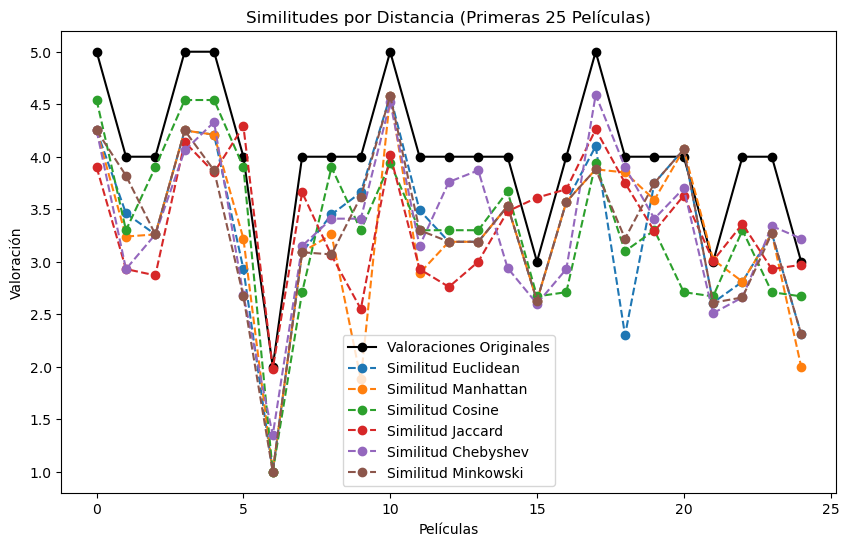

In [71]:
similitudes_dict = {
    "Euclidean": similitud_euclideana,
    "Manhattan": similitud_manhattan,
    "Cosine": similitud_cosine,
    "Jaccard": similitud_jaccard,
    "Chebyshev": similitud_chebyshev,
    "Minkowski": similitud_minkowski
}
graficar_similitudes(valoraciones_peliculas, similitudes_dict,limit=25)

In [72]:
mejor_distancia_global, comparacion_errores = calcular_accuracy_promedio_por_distancia(valoraciones_peliculas, similitudes_dict)

print(f"La mejor distancia global es {mejor_distancia_global}")
for distancia, datos in comparacion_errores.items():
    print(f"Distancia: {distancia}")
    print(f"  Accuracy Promedio: {datos['accuracy_promedio']:.2f}%")


La mejor distancia global es Cosine
Distancia: Euclidean
  Accuracy Promedio: 75.32%
Distancia: Manhattan
  Accuracy Promedio: 77.35%
Distancia: Cosine
  Accuracy Promedio: 79.00%
Distancia: Jaccard
  Accuracy Promedio: 77.08%
Distancia: Chebyshev
  Accuracy Promedio: 78.36%
Distancia: Minkowski
  Accuracy Promedio: 76.57%


# ` Análisis de la Mejor Distancia para Recomendación`

**Distancia Globalmente Óptima**:  
La distancia **Cosine** ofrece el mayor accuracy promedio, con un **79.00%**, y es la mejor opción global cuando buscamos la mayor precisión en relación a las valoraciones originales. En este análisis, se usó un valor de \( k = 2 \) vecinos.

**Elección del Valor de \( k \) y la Distancia**:

- Para un **número reducido de vecinos** (bajo \( k entre 2 y 5\)), **Cosine o Chebyshev** son las mejores elecciones.
- Para un **número mayor de vecinos** (como \( k > 10 \)), **Cosine** es preferible ya que puede capturar relaciones complejas entre ítems, reflejando contextos amplios en las recomendaciones, todo y que en esta base de datos, no ha demostrado dar tan buenos resultados, sigue siendo la mejor opción para utilizar una vecinidad alta, pero como la diferencia es tan grande con una K mas baja, esta vez eligiremos la distancia baja.

En conclusión, usaré Cosine ya que da el mejor resultado, pero incrementaré la K un poco, para intentar no dejar el mínimo, por tanto me quedaré con K=5

**Resultados por Distancia:**

- Distancia **Euclidean** (vecinos = 2): Accuracy Promedio de **75.32%**
- Distancia **Manhattan** (vecinos = 2): Accuracy Promedio de **77.35%**
- Distancia **Cosine** (vecinos = 2): Accuracy Promedio de **79%**
- Distancia **Jaccard** (vecinos = 4): Accuracy Promedio de **77.08%**
- Distancia **Chebyshev** (vecinos = 2): Accuracy Promedio de **78.36%**
- Distancia **Minkowski** (vecinos = 2): Accuracy Promedio de **76.57%**



## 6. Accuracy Promedio

In [73]:
def calcular_porcentaje_accuracy_promedio(valoraciones_peliculas, similitudes):
    # Calcular la precisión individual para cada valoración
    accuracies_individuales = [1 - abs(valoracion - prediccion) / valoracion if valoracion != 0 else 0
        for valoracion, prediccion in zip(valoraciones_peliculas, similitudes)
    ]
    
    accuracy_promedio = sum(accuracies_individuales) / len(accuracies_individuales) * 100 if accuracies_individuales else 0
    
    return accuracy_promedio


Para el accuracy final haré la estimación con la misma cantidad de usuarios que en la base de datos de 100K, por supuesto no se estarán evaluando 100K de valoraciones, esto varia de cada pelicula, pero en principio deberian ser muchas mas, y por tanto obtener un accuracy mejor

In [74]:
def total_accuracy(n_usuarios):
    minimo_vecinos = 20
    mejores_vecinos = 5
    lista_usuarios = list(df['userId'].unique())[0:(n_usuarios-1)]
    usuarios_vistos = 0
    sum_accuracys = 0 
    for usuario in lista_usuarios:
        print("Usuario nº: " + str(usuario))
        usuarios_vistos += 1
        lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario, escasez)
        lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(
            lista_peliculas_usuario=lista_peliculas, 
            valoraciones_peliculas=valoraciones_peliculas, 
            matriz_normalizada=matriz_normalizada, 
            vecinos_min=minimo_vecinos
        )
        similitud_cosine = similitud_distancias(
            lista_peliculas_usuario=lista_peliculas, 
            usuario=usuario, 
            distancia_escogida='cosine', 
            vecinos=mejores_vecinos
        )
        
        accuracy_promedio = calcular_porcentaje_accuracy_promedio(valoraciones_peliculas, similitud_cosine) # Calcular accuracy promedio como un valor escalar
        sum_accuracys += accuracy_promedio  

    print(f"Accuracy promedio: {sum_accuracys / usuarios_vistos:.2f}%")


n_usuarios = 610
total_accuracy(n_usuarios = n_usuarios)




Usuario nº: 1
Usuario nº: 2
Usuario nº: 3
Usuario nº: 4
Usuario nº: 5
Usuario nº: 6
Usuario nº: 7
Usuario nº: 8
Usuario nº: 9
Usuario nº: 10
Usuario nº: 11
Usuario nº: 12
Usuario nº: 13
Usuario nº: 14
Usuario nº: 15
Usuario nº: 16
Usuario nº: 17
Usuario nº: 18
Usuario nº: 19
Usuario nº: 20
Usuario nº: 21
Usuario nº: 22
Usuario nº: 23
Usuario nº: 24
Usuario nº: 25
Usuario nº: 26
Usuario nº: 27
Usuario nº: 28
Usuario nº: 29
Usuario nº: 30
Usuario nº: 31
Usuario nº: 32
Usuario nº: 33
Usuario nº: 34
Usuario nº: 35
Usuario nº: 36
Usuario nº: 37
Usuario nº: 38
Usuario nº: 39
Usuario nº: 40
Usuario nº: 41
Usuario nº: 42
Usuario nº: 43
Usuario nº: 44
Usuario nº: 45
Usuario nº: 46
Usuario nº: 47
Usuario nº: 48
Usuario nº: 49
Usuario nº: 50
Usuario nº: 51
Usuario nº: 52
Usuario nº: 53
Usuario nº: 54
Usuario nº: 55
Usuario nº: 56
Usuario nº: 57
Usuario nº: 58
Usuario nº: 59
Usuario nº: 60
Usuario nº: 61
Usuario nº: 62
Usuario nº: 63
Usuario nº: 64
Usuario nº: 65
Usuario nº: 66
Usuario nº: 67
Usua

In [76]:
def total_accuracy(n_usuarios):
    minimo_vecinos = 20
    mejores_vecinos = 18
    lista_usuarios = list(df['userId'].unique())[0:(n_usuarios-1)]
    usuarios_vistos = 0
    sum_accuracys = 0 
    for usuario in lista_usuarios:
        print("Usuario nº: " + str(usuario))
        usuarios_vistos += 1
        lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario, escasez)
        lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(
            lista_peliculas_usuario=lista_peliculas, 
            valoraciones_peliculas=valoraciones_peliculas, 
            matriz_normalizada=matriz_normalizada, 
            vecinos_min=minimo_vecinos
        )
        similitud_cosine = similitud_distancias(
            lista_peliculas_usuario=lista_peliculas, 
            usuario=usuario, 
            distancia_escogida='cosine', 
            vecinos=mejores_vecinos
        )
        
        accuracy_promedio = calcular_porcentaje_accuracy_promedio(valoraciones_peliculas, similitud_cosine) # Calcular accuracy promedio como un valor escalar
        sum_accuracys += accuracy_promedio  

    print(f"Accuracy promedio: {sum_accuracys / usuarios_vistos:.2f}%")


n_usuarios = 610
total_accuracy(n_usuarios = n_usuarios)

Usuario nº: 1
Usuario nº: 2
Usuario nº: 3
Usuario nº: 4
Usuario nº: 5
Usuario nº: 6
Usuario nº: 7
Usuario nº: 8
Usuario nº: 9
Usuario nº: 10
Usuario nº: 11
Usuario nº: 12
Usuario nº: 13
Usuario nº: 14
Usuario nº: 15
Usuario nº: 16
Usuario nº: 17
Usuario nº: 18
Usuario nº: 19
Usuario nº: 20
Usuario nº: 21
Usuario nº: 22
Usuario nº: 23
Usuario nº: 24
Usuario nº: 25
Usuario nº: 26
Usuario nº: 27
Usuario nº: 28
Usuario nº: 29
Usuario nº: 30
Usuario nº: 31
Usuario nº: 32
Usuario nº: 33
Usuario nº: 34
Usuario nº: 35
Usuario nº: 36
Usuario nº: 37
Usuario nº: 38
Usuario nº: 39
Usuario nº: 40
Usuario nº: 41
Usuario nº: 42
Usuario nº: 43
Usuario nº: 44
Usuario nº: 45
Usuario nº: 46
Usuario nº: 47
Usuario nº: 48
Usuario nº: 49
Usuario nº: 50
Usuario nº: 51
Usuario nº: 52
Usuario nº: 53
Usuario nº: 54
Usuario nº: 55
Usuario nº: 56
Usuario nº: 57
Usuario nº: 58
Usuario nº: 59
Usuario nº: 60
Usuario nº: 61
Usuario nº: 62
Usuario nº: 63
Usuario nº: 64
Usuario nº: 65
Usuario nº: 66
Usuario nº: 67
Usua

Para demostrar que no es necesario evaluar una mayor cantidad de usuarios probaré haciendolo con 2000, como se puede ver no solo la ejecución ha tardado 472 minutos (350 minutos mas), sino que la direrencia de accuracy es del 0,05%

In [75]:
def total_accuracy(n_usuarios):
    minimo_vecinos = 20
    mejores_vecinos = 5
    lista_usuarios = list(df['userId'].unique())[0:(n_usuarios-1)]
    usuarios_vistos = 0
    sum_accuracys = 0 
    for usuario in lista_usuarios:
        print("Usuario nº: " + str(usuario))
        usuarios_vistos += 1
        lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario, escasez)
        lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(
            lista_peliculas_usuario=lista_peliculas, 
            valoraciones_peliculas=valoraciones_peliculas, 
            matriz_normalizada=matriz_normalizada, 
            vecinos_min=minimo_vecinos
        )
        similitud_cosine = similitud_distancias(
            lista_peliculas_usuario=lista_peliculas, 
            usuario=usuario, 
            distancia_escogida='cosine', 
            vecinos=mejores_vecinos
        )
        
        accuracy_promedio = calcular_porcentaje_accuracy_promedio(valoraciones_peliculas, similitud_cosine) # Calcular accuracy promedio como un valor escalar
        sum_accuracys += accuracy_promedio  

    print(f"Accuracy promedio: {sum_accuracys / usuarios_vistos:.2f}%")


n_usuarios = 2000
total_accuracy(n_usuarios = n_usuarios)




Usuario nº: 1
Usuario nº: 2
Usuario nº: 3
Usuario nº: 4
Usuario nº: 5
Usuario nº: 6
Usuario nº: 7
Usuario nº: 8
Usuario nº: 9
Usuario nº: 10
Usuario nº: 11
Usuario nº: 12
Usuario nº: 13
Usuario nº: 14
Usuario nº: 15
Usuario nº: 16
Usuario nº: 17
Usuario nº: 18
Usuario nº: 19
Usuario nº: 20
Usuario nº: 21
Usuario nº: 22
Usuario nº: 23
Usuario nº: 24
Usuario nº: 25
Usuario nº: 26
Usuario nº: 27
Usuario nº: 28
Usuario nº: 29
Usuario nº: 30
Usuario nº: 31
Usuario nº: 32
Usuario nº: 33
Usuario nº: 34
Usuario nº: 35
Usuario nº: 36
Usuario nº: 37
Usuario nº: 38
Usuario nº: 39
Usuario nº: 40
Usuario nº: 41
Usuario nº: 42
Usuario nº: 43
Usuario nº: 44
Usuario nº: 45
Usuario nº: 46
Usuario nº: 47
Usuario nº: 48
Usuario nº: 49
Usuario nº: 50
Usuario nº: 51
Usuario nº: 52
Usuario nº: 53
Usuario nº: 54
Usuario nº: 55
Usuario nº: 56
Usuario nº: 57
Usuario nº: 58
Usuario nº: 59
Usuario nº: 60
Usuario nº: 61
Usuario nº: 62
Usuario nº: 63
Usuario nº: 64
Usuario nº: 65
Usuario nº: 66
Usuario nº: 67
Usua

## 7. Predicciones

Ahora que ya sabemos que distancia y que K nos corresponde podemos hacer la prediccion para el usuario que deseemos, esta predicción nos devolverá las 10 mejores predicciones del usuario, las cuales se le recomendarían

In [77]:
import pandas as pd

# Cargar los archivos CSV proporcionados
movies = pd.read_csv('BBDD_1M/movies.dat', delimiter='::', engine='python', header=None, names=['movieId', 'title', 'genres'], encoding='ISO-8859-1')
ratings = pd.read_csv('BBDD_1M/ratings.dat', delimiter='::', engine='python', header=None, names=['userId', 'movieId', 'rating', 'timestamp'], encoding='ISO-8859-1')
# Mostrar una muestra de los datos para asegurarnos de que se han cargado correctamente
print(movies.head())
print(ratings.head())


   movieId                               title                        genres
0        1                    Toy Story (1995)   Animation|Children's|Comedy
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
2        3             Grumpier Old Men (1995)                Comedy|Romance
3        4            Waiting to Exhale (1995)                  Comedy|Drama
4        5  Father of the Bride Part II (1995)                        Comedy
   userId  movieId  rating  timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291


In [78]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

def peliculas_no_valoradas(usuario, matriz_escasez):    
    peliculas_no_votadas = matriz_escasez.loc[usuario][matriz_escasez.loc[usuario].isna()].index.tolist() # Filtrar las películas que el usuario no ha valorado (NaN en la matriz de escasez)
    
    return peliculas_no_votadas

def peliculas_con_minimo_vecinos(lista_peliculas_usuario, usuario_pelicula, vecinos_min):
    # Filtramos solo las películas con al menos 'vecinos_min' valoraciones distintas de 0
    peliculas_filtradas = []

    for pelicula in lista_peliculas_usuario:
        # Asegurarse de que 'pelicula' es el identificador correcto que corresponde a las columnas de usuario_pelicula
        if pelicula not in usuario_pelicula.columns:
            continue
        usuarios_que_vieron_la_pelicula = usuario_pelicula[usuario_pelicula[pelicula].notna() & (usuario_pelicula[pelicula] != 0)][pelicula]  # Seleccionamos los usuarios que vieron la película
        
        # Si el número de usuarios que vieron la película es mayor o igual a 'vecinos_min', la añadimos a la lista
        if len(usuarios_que_vieron_la_pelicula) >= vecinos_min:
            peliculas_filtradas.append(pelicula)

    return peliculas_filtradas

def reescalar_prediccion(prediccion_normalizada, id_usuario, matriz_escasez_original, min_rating=0.5, max_rating=5.0):
    # Calculamos la media y desviación estándar del usuario específico
    media_usuario = matriz_escasez_original.loc[id_usuario].mean(skipna=True)
    desviacion_usuario = matriz_escasez_original.loc[id_usuario].std(skipna=True)
    
    # Si la desviación estándar es válida, aplicamos el reescalado
    if not pd.isna(media_usuario) and not pd.isna(desviacion_usuario):
        prediccion_reescalada = (prediccion_normalizada * desviacion_usuario) + media_usuario
        prediccion_reescalada = np.clip(round(prediccion_reescalada, 2), min_rating, max_rating) # Clipping para mantener la predicción dentro del rango y redondeo
    else:
        prediccion_reescalada = np.nan
    
    return prediccion_reescalada

def recomendar_peliculas(usuario, escasez, usuario_pelicula, movies,mejores_vecinos, distancia_escogida='manhattan', vecinos=20, top_n=10, limite_peliculas_no_votadas=100):
   
    # Obtener las películas que el usuario no ha valorado
    peliculas_no_votadas = peliculas_no_valoradas(usuario, escasez)
    
    # Limitar el número de películas no votadas que vamos a evaluar
    if len(peliculas_no_votadas) > limite_peliculas_no_votadas:
        peliculas_no_votadas = np.random.choice(peliculas_no_votadas, limite_peliculas_no_votadas, replace=False)
    
    # Filtrar las películas con al menos 'vecinos_min' valoraciones distintas de 0
    peliculas_no_votadas = peliculas_con_minimo_vecinos(peliculas_no_votadas, usuario_pelicula, vecinos_min=vecinos)
    
    # Predecir las valoraciones para las películas no votadas
    predicciones = []
    for pelicula in peliculas_no_votadas:
        # Seleccionamos los usuarios que han valorado la película
        usuarios_que_vieron_la_pelicula = usuario_pelicula[usuario_pelicula[pelicula].notna() & (usuario_pelicula[pelicula] != 0)]
        
        if usuarios_que_vieron_la_pelicula.empty:
            continue  # Saltar si no hay usuarios con valoraciones para esta película
        
        # Datos del usuario objetivo para la predicción
        usuario_objetivo = usuario_pelicula.iloc[[usuario]]

        # Reemplazar NaNs con ceros en los datos de entrada para evitar errores
        usuarios_que_vieron_la_pelicula = usuarios_que_vieron_la_pelicula.fillna(0)
        usuario_objetivo = usuario_objetivo.fillna(0)

        # Modelo KNN para la predicción
        knn = KNeighborsRegressor(metric=distancia_escogida, n_neighbors=mejores_vecinos)
        knn.fit(usuarios_que_vieron_la_pelicula, usuario_pelicula.loc[usuarios_que_vieron_la_pelicula.index, pelicula])
        
        # Predecir la valoración del usuario para la película
        prediccion_usuario = knn.predict(usuario_objetivo)[0]
        prediccion_reescalada = reescalar_prediccion(prediccion_usuario, usuario, escasez)
        
        # Guardar la predicción con el ID de la película
        predicciones.append((pelicula, prediccion_reescalada))
    
    # Ordenar las predicciones por valoración en orden descendente
    predicciones.sort(key=lambda x: x[1], reverse=True)
    
    # Seleccionar las top_n mejores películas
    mejores_peliculas = predicciones[:top_n]
    
    # Obtener los nombres de las mejores películas
    recomendaciones = pd.DataFrame(mejores_peliculas, columns=['movieId', 'Predicted Rating']).merge(movies, on='movieId')
    
    return recomendaciones[['title', 'Predicted Rating', 'genres']]


In [79]:
usuario_id = 6
mejores_vecinos_cosine = 18
min_vecinos = 20

In [80]:
recomendaciones = recomendar_peliculas(usuario_id, escasez, matriz_normalizada, movies,mejores_vecinos_cosine, distancia_escogida='cosine', vecinos=min_vecinos, top_n=10)

recomendaciones.head(10)

,title,Predicted Rating,genres
0,Saving Private Ryan (1998),4.65,Action|Drama|War
1,"Decline of Western Civilization, The (1981)",4.52,Documentary
2,Nights of Cabiria (Le Notti di Cabiria) (1957),4.41,Drama
3,"Exorcist, The (1973)",4.36,Horror
4,"Producers, The (1968)",4.24,Comedy|Musical
5,Lonely Are the Brave (1962),4.23,Drama|Western
6,Some Mother's Son (1996),4.20,Drama
7,Children of the Revolution (1996),4.18,Comedy
8,This Is Spinal Tap (1984),4.18,Comedy|Drama|Musical
9,Rain Man (1988),4.15,Drama


Tambien podemos buscar al usuario con la media de valoraciones mas baja posible, para ver si las predicciones se hacen entorno a esos valores.

En el siguiente ejemplo podemos ver como el usuario 442 tiene una media de 1.275, y las valoraciones se hacen entorno a esos datos

In [81]:
# Encontrar al usuario con la media de valoraciones más baja
def usuario_media_mas_baja(matriz_escasez):
    # Calcular la media de valoraciones de cada usuario, ignorando los NaN
    medias_usuarios = matriz_escasez.mean(axis=1, skipna=True)
    
    # Encontrar el usuario con la media más baja
    usuario_min_media = medias_usuarios.idxmin()
    media_min = medias_usuarios.min()
    
    print(f"Usuario con la media más baja: {usuario_min_media}")
    print(f"Media de valoraciones del usuario: {media_min}")
    
    return usuario_min_media

# Ejemplo de ejecución para encontrar al usuario con la media más baja
usuario_con_media_baja = usuario_media_mas_baja(escasez)


Usuario con la media más baja: 3598
Media de valoraciones del usuario: 1.0153846153846153


In [82]:
usuario_id = usuario_con_media_baja
recomendaciones = recomendar_peliculas(usuario_id, escasez, matriz_normalizada, movies,mejores_vecinos_cosine, distancia_escogida='cosine', vecinos=min_vecinos, top_n=10)

recomendaciones.head(10)

,title,Predicted Rating,genres
0,"Fifth Element, The (1997)",1.12,Action|Sci-Fi
1,Dersu Uzala (1974),1.09,Adventure|Drama
2,His Girl Friday (1940),1.09,Comedy
3,Watership Down (1978),1.08,Animation|Children's|Drama|Fantasy
4,"Secret of NIMH, The (1982)",1.08,Animation|Children's
5,Psycho (1960),1.07,Horror|Thriller
6,Rebel Without a Cause (1955),1.07,Drama
7,Ponette (1996),1.07,Drama
8,To Sir with Love (1967),1.06,Drama
9,Hoosiers (1986),1.06,Drama


También podemos ver que usuario es el que mas se parece a otro usuario, esto lo haremos con el coeficiente de pearson

In [83]:
usuario_id = 3
def usuario_mas_similar(usuario_id, escasez, min_peliculas_comunes=5):
    # Extraer las valoraciones del usuario objetivo
    valoraciones_usuario = escasez.loc[usuario_id]
    
    # Calcular la correlación de Pearson entre el usuario objetivo y todos los demás usuarios
    correlaciones = escasez.corrwith(valoraciones_usuario, axis=1, method='pearson')
    
    # Eliminar la correlación del usuario consigo mismo
    correlaciones = correlaciones.drop(index=usuario_id)
    
    # Filtrar usuarios con pocas valoraciones en común
    peliculas_comunes = escasez.notna().multiply(valoraciones_usuario.notna(), axis=0).sum(axis=1)
    correlaciones = correlaciones[peliculas_comunes >= min_peliculas_comunes]
    
    # Eliminar usuarios con una correlación de 1 (idénticas valoraciones)
    correlaciones = correlaciones[correlaciones < 1]
    
    # Encontrar el usuario con la mayor correlación positiva
    usuario_mas_similar = correlaciones.idxmax()
    coeficiente_correlacion = correlaciones.max()
    
    return usuario_mas_similar, coeficiente_correlacion

# Ejemplo de uso
usuario_similar, correlacion = usuario_mas_similar(usuario_id, escasez)
print(f"El usuario más similar al usuario {usuario_id} es {usuario_similar} con un coeficiente de correlación de Pearson de {correlacion:.2f}.")



El usuario más similar al usuario 3 es 1049 con un coeficiente de correlación de Pearson de 1.00.
